# Extended-Context vs Full-Text Model — Head-to-Head Comparison

Compares per-article classifications between:
- **NEW** model: `results_sept_oct_rel_mapped.csv` (187 Sept–Oct articles, just re-classified with GT-300 few-shot pool)
- **OLD** model: `results_gt_ext200_mapped.csv` (1,163 articles, restricted to the same 187 ids)

Both CSVs are mapped with `map_intraday.py` so the DXY price columns and rolling-SD `true_criticality` are identical across files — every difference we see is driven by the classification models, not by the truth labels.

Sections:
1. Load & join on `id`
2. Disagreement summary (relevance, criticality, tier, event, direction)
3. DXY-movement range for critical vs non-critical (per model)
4. Per-event and per-tier critical rate + volatility lift
5. Case-level differences (the specific articles where the two models disagreed)
6. Mann-Whitney U tests — between-model movement distributions
7. Precision / recall vs rolling-SD ground truth
8. Directional accuracy head-to-head
9. Headline numbers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 11,
})

TEAL  = '#1D9E75'
CORAL = '#D85A30'
GRAY  = '#888780'
BLUE  = '#378ADD'
AMBER = '#BA7517'

HORIZONS = ['pct_5m', 'pct_15m', 'pct_1h', 'pct_4h', 'pct_1d']
H_LABELS = ['5m', '15m', '1h', '4h', '1d']

## 1 — Load & join on `id`

The NEW run has 187 articles. We restrict the OLD mapped file to those same 187 ids so every row compares the two models on **the same article with the same truth label**.

In [2]:
new = pd.read_csv('data/results_sept_oct_rel_mapped.csv')
old_all = pd.read_csv('data/results_gt_ext200_mapped.csv')
old = old_all[old_all['id'].isin(new['id'])].copy()

print(f'NEW (sept-oct re-classification) : {len(new)} articles')
print(f'OLD (gt_ext200, full corpus)     : {len(old_all)} articles')
print(f'OLD restricted to NEW ids        : {len(old)} articles')
print(f'Missing from OLD                 : {len(new) - len(old)}')

# Tag so we can stack
new['model'] = 'NEW'
old['model'] = 'OLD'

# Columns we care about from classifiers
CLASS_COLS = ['is_relevant', 'is_critical', 'content_type', 'event_number',
              'event_name', 'event_tier', 'criticality_level', 'direction',
              'direction_confidence', 'table_used']
# Columns shared from truth / price side
TRUTH_COLS = ['true_criticality', 'true_direction', 'sd_15m'] + HORIZONS

joined = new.merge(
    old[['id'] + CLASS_COLS],
    on='id', suffixes=('_new', '_old')
)
print(f'\nJoined rows                       : {len(joined)}')

NEW (sept-oct re-classification) : 187 articles
OLD (gt_ext200, full corpus)     : 1163 articles
OLD restricted to NEW ids        : 187 articles
Missing from OLD                 : 0

Joined rows                       : 187


## 2 — Disagreement Summary

For each categorical field, how often do the two models give the same answer on the same article?

In [3]:
fields = [
    ('is_relevant',       'is_relevant_new',       'is_relevant_old'),
    ('is_critical',       'is_critical_new',       'is_critical_old'),
    ('criticality_level', 'criticality_level_new', 'criticality_level_old'),
    ('event_tier',        'event_tier_new',        'event_tier_old'),
    ('event_number',      'event_number_new',      'event_number_old'),
    ('content_type',      'content_type_new',      'content_type_old'),
    ('direction',         'direction_new',         'direction_old'),
]

rows = []
for name, cn, co in fields:
    both = joined[[cn, co]].dropna()
    agree = (both[cn] == both[co]).sum()
    total = len(both)
    rows.append({
        'field': name,
        'n (both labeled)': total,
        'agree': agree,
        'disagree': total - agree,
        'agreement rate': f'{agree/total*100:.1f}%' if total else 'n/a',
    })
agree_df = pd.DataFrame(rows).set_index('field')
display(agree_df)

,n (both labeled),agree,disagree,agreement rate
field,,,,
is_relevant,187,176,11,94.1%
is_critical,187,163,24,87.2%
criticality_level,176,152,24,86.4%
event_tier,176,160,16,90.9%
event_number,187,151,36,80.7%
content_type,187,163,24,87.2%
direction,176,135,41,76.7%


In [4]:
# Simple model-level counts
summary = pd.DataFrame({
    'NEW': [
        joined['is_relevant_new'].sum(),
        joined['is_critical_new'].sum(),
        (joined['criticality_level_new'] == 'high').sum(),
        (joined['criticality_level_new'] == 'not high').sum(),
    ],
    'OLD': [
        joined['is_relevant_old'].sum(),
        joined['is_critical_old'].sum(),
        (joined['criticality_level_old'] == 'high').sum(),
        (joined['criticality_level_old'] == 'not high').sum(),
    ],
}, index=['relevant', 'critical (flag)', 'criticality_level=high', 'criticality_level=not high'])
print('Count by model (same 187 articles):')
display(summary)

Count by model (same 187 articles):


,NEW,OLD
relevant,176,187
critical (flag),31,39
criticality_level=high,31,39
criticality_level=not high,145,148


In [5]:
# Criticality agreement matrix (2x2)
cm = pd.crosstab(
    joined['is_critical_new'].map({True: 'NEW: critical', False: 'NEW: not'}),
    joined['is_critical_old'].map({True: 'OLD: critical', False: 'OLD: not'}),
    margins=True, margins_name='total',
)
print('Criticality agreement matrix (same 187 articles):')
display(cm)

Criticality agreement matrix (same 187 articles):


is_critical_old,OLD: critical,OLD: not,total
is_critical_new,,,
NEW: critical,23,8,31
NEW: not,16,140,156
total,39,148,187


## 3 — DXY Movement Range for Critical vs Non-Critical

For each model, what is the range of actual DXY moves among articles tagged critical vs not critical? The truth column (`pct_15m` etc.) is identical across both files — only the criticality flag differs.

In [6]:
def summary_by_flag(df, flag_col, horizons=HORIZONS):
    out = []
    for is_crit, label in [(True, 'critical'), (False, 'not critical')]:
        grp = df[df[flag_col] == is_crit]
        row = {'flag': label, 'n': len(grp)}
        for h in horizons:
            abs_vals = grp[h].abs().dropna()
            row[f'|{h}| mean'] = round(abs_vals.mean(), 5) if len(abs_vals) else np.nan
            row[f'|{h}| med']  = round(abs_vals.median(), 5) if len(abs_vals) else np.nan
            row[f'|{h}| max']  = round(abs_vals.max(), 5) if len(abs_vals) else np.nan
        out.append(row)
    return pd.DataFrame(out).set_index('flag')

print('NEW model:')
display(summary_by_flag(joined, 'is_critical_new'))
print('\nOLD model:')
display(summary_by_flag(joined, 'is_critical_old'))

NEW model:


,n,|pct_5m| mean,|pct_5m| med,|pct_5m| max,|pct_15m| mean,|pct_15m| med,|pct_15m| max,|pct_1h| mean,|pct_1h| med,|pct_1h| max,|pct_4h| mean,|pct_4h| med,|pct_4h| max,|pct_1d| mean,|pct_1d| med,|pct_1d| max
flag,,,,,,,,,,,,,,,,
critical,31,0.04089,0.03049,0.26893,0.05976,0.03039,0.39438,0.09226,0.07071,0.43527,0.1770,0.16355,0.54165,0.31084,0.22539,0.74906
not critical,156,0.01524,0.01021,0.08305,0.03069,0.02044,0.34726,0.06093,0.04074,0.53981,0.1166,0.07197,0.66047,0.28808,0.25388,1.06924



OLD model:


,n,|pct_5m| mean,|pct_5m| med,|pct_5m| max,|pct_15m| mean,|pct_15m| med,|pct_15m| max,|pct_1h| mean,|pct_1h| med,|pct_1h| max,|pct_4h| mean,|pct_4h| med,|pct_4h| max,|pct_1d| mean,|pct_1d| med,|pct_1d| max
flag,,,,,,,,,,,,,,,,
critical,39,0.03564,0.02045,0.26893,0.06446,0.03062,0.39438,0.09901,0.07074,0.43527,0.15469,0.14316,0.49025,0.33465,0.28135,0.74906
not critical,148,0.01534,0.01021,0.08305,0.02785,0.02037,0.18367,0.05732,0.04053,0.53981,0.11933,0.08078,0.66047,0.28122,0.23111,1.06924


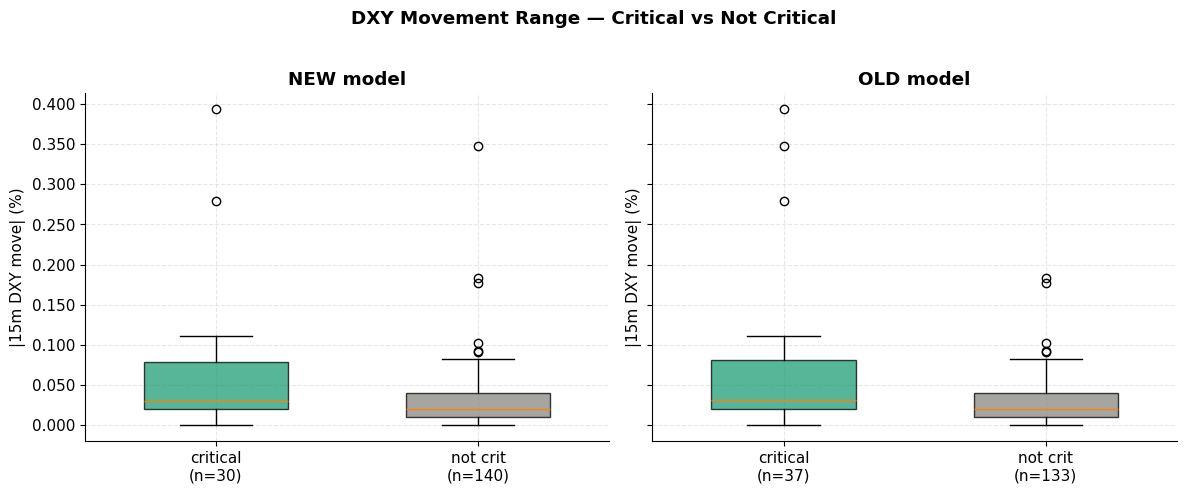

In [7]:
# Box/strip plot: |pct_15m| by critical flag, side-by-side for each model
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, (flag_col, title) in zip(axes, [
    ('is_critical_new', 'NEW model'),
    ('is_critical_old', 'OLD model'),
]):
    crit     = joined.loc[joined[flag_col] == True,  'pct_15m'].abs().dropna()
    not_crit = joined.loc[joined[flag_col] == False, 'pct_15m'].abs().dropna()
    bp = ax.boxplot([crit, not_crit], labels=[f'critical\n(n={len(crit)})', f'not crit\n(n={len(not_crit)})'],
                    patch_artist=True, showfliers=True, widths=0.55)
    for patch, col in zip(bp['boxes'], [TEAL, GRAY]):
        patch.set_facecolor(col); patch.set_alpha(0.75)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('|15m DXY move| (%)')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.3f}'))
plt.suptitle('DXY Movement Range — Critical vs Not Critical', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

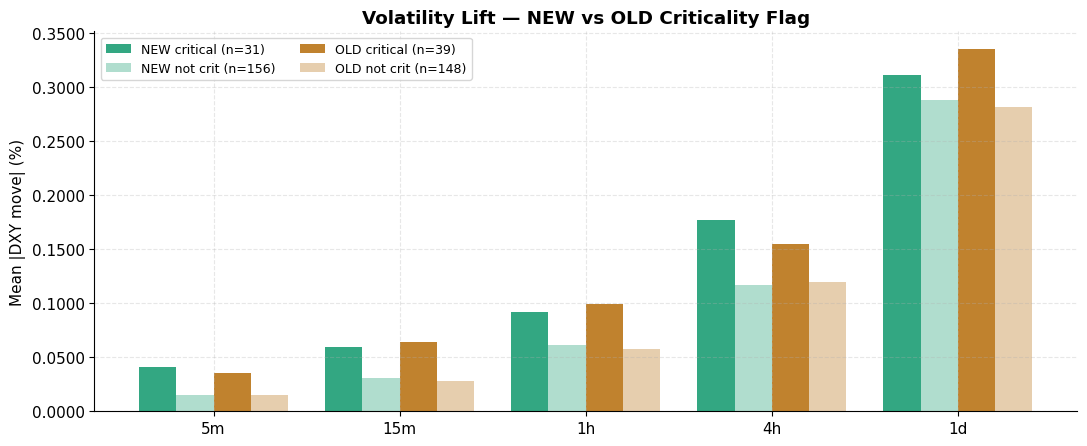


Lift (critical / not-critical) mean |move|:


,NEW lift,OLD lift
horizon,,
5m,2.68x,2.32x
15m,1.95x,2.31x
1h,1.51x,1.73x
4h,1.52x,1.30x
1d,1.08x,1.19x


In [8]:
# Mean |move| at each horizon, both models on the same axes
fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(HORIZONS)); w = 0.2

groups = [
    ('NEW critical',     joined[joined['is_critical_new'] == True],  TEAL,  0.9),
    ('NEW not crit',     joined[joined['is_critical_new'] == False], TEAL,  0.35),
    ('OLD critical',     joined[joined['is_critical_old'] == True],  AMBER, 0.9),
    ('OLD not crit',     joined[joined['is_critical_old'] == False], AMBER, 0.35),
]
for i, (label, grp, color, alpha) in enumerate(groups):
    means = [grp[h].abs().mean() for h in HORIZONS]
    ax.bar(x + (i - 1.5) * w, means, w, label=f'{label} (n={len(grp)})', color=color, alpha=alpha)
ax.set_xticks(x); ax.set_xticklabels(H_LABELS)
ax.set_ylabel('Mean |DXY move| (%)')
ax.set_title('Volatility Lift — NEW vs OLD Criticality Flag', fontweight='bold')
ax.legend(ncol=2, fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.4f}'))
plt.tight_layout()
plt.show()

# Lift ratios
print('\nLift (critical / not-critical) mean |move|:')
lift_rows = []
for h, hl in zip(HORIZONS, H_LABELS):
    new_lift = joined.loc[joined['is_critical_new']==True, h].abs().mean() / joined.loc[joined['is_critical_new']==False, h].abs().mean()
    old_lift = joined.loc[joined['is_critical_old']==True, h].abs().mean() / joined.loc[joined['is_critical_old']==False, h].abs().mean()
    lift_rows.append({'horizon': hl, 'NEW lift': f'{new_lift:.2f}x', 'OLD lift': f'{old_lift:.2f}x'})
display(pd.DataFrame(lift_rows).set_index('horizon'))

## 4 — Per-Event and Per-Tier Breakdown

How does each model's critical rate and realized volatility vary by event type and tier?

In [9]:
def tier_breakdown(df, tier_col, crit_col):
    out = []
    for tier in sorted(df[tier_col].dropna().unique()):
        g = df[df[tier_col] == tier]
        crit_n = g[crit_col].sum() if g[crit_col].dtype == bool else (g[crit_col] == True).sum()
        out.append({
            'tier': int(tier),
            'n articles': len(g),
            'n critical': int(crit_n),
            'critical rate': f'{crit_n/len(g)*100:.1f}%' if len(g) else 'n/a',
            'mean |15m|':   round(g['pct_15m'].abs().mean(), 5),
            'mean |1h|':    round(g['pct_1h'].abs().mean(), 5),
        })
    return pd.DataFrame(out).set_index('tier')

print('NEW model — by tier:')
display(tier_breakdown(joined, 'event_tier_new', 'is_critical_new'))
print('\nOLD model — by tier:')
display(tier_breakdown(joined, 'event_tier_old', 'is_critical_old'))

NEW model — by tier:


,n articles,n critical,critical rate,mean |15m|,mean |1h|
tier,,,,,
1,58,17,29.3%,0.04969,0.09622
2,11,3,27.3%,0.02543,0.04583
3,68,8,11.8%,0.03031,0.05028
4,39,3,7.7%,0.02439,0.05404



OLD model — by tier:


,n articles,n critical,critical rate,mean |15m|,mean |1h|
tier,,,,,
1,56,29,51.8%,0.04682,0.08772
2,11,3,27.3%,0.03355,0.05087
3,65,6,9.2%,0.02856,0.05468
4,55,1,1.8%,0.03195,0.05925


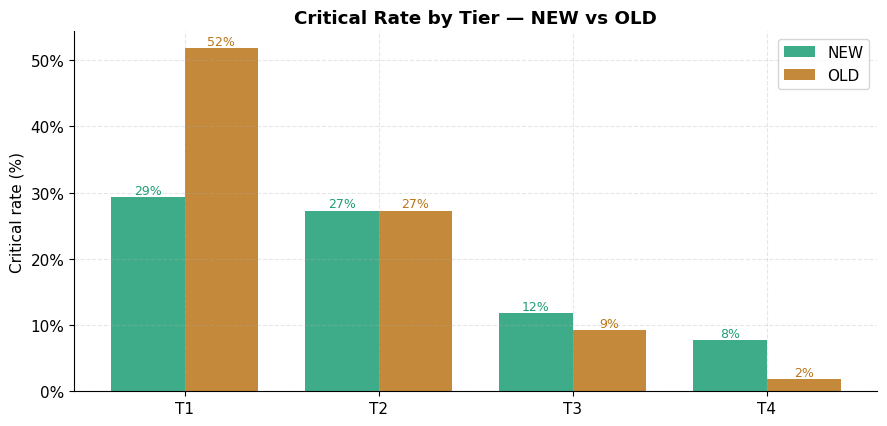

In [10]:
# Side-by-side critical-rate by tier
tiers = sorted(set(joined['event_tier_new'].dropna().unique()) | set(joined['event_tier_old'].dropna().unique()))
tiers = [int(t) for t in tiers]

new_rates = []; old_rates = []
for t in tiers:
    gn = joined[joined['event_tier_new'] == t]
    go = joined[joined['event_tier_old'] == t]
    new_rates.append(gn['is_critical_new'].mean()*100 if len(gn) else 0)
    old_rates.append(go['is_critical_old'].mean()*100 if len(go) else 0)

fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(tiers)); w = 0.38
ax.bar(x - w/2, new_rates, w, label='NEW', color=TEAL, alpha=0.85)
ax.bar(x + w/2, old_rates, w, label='OLD', color=AMBER, alpha=0.85)
for i, (nr, or_) in enumerate(zip(new_rates, old_rates)):
    ax.text(i - w/2, nr + 0.5, f'{nr:.0f}%', ha='center', fontsize=9, color=TEAL)
    ax.text(i + w/2, or_ + 0.5, f'{or_:.0f}%', ha='center', fontsize=9, color=AMBER)
ax.set_xticks(x); ax.set_xticklabels([f'T{t}' for t in tiers])
ax.set_ylabel('Critical rate (%)'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Critical Rate by Tier — NEW vs OLD', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Per-event critical rate for both models (events touched by at least one model)
ev_rows = []
events = sorted(set(joined['event_number_new'].dropna().unique()) | set(joined['event_number_old'].dropna().unique()))
for e in events:
    gn = joined[joined['event_number_new'] == e]
    go = joined[joined['event_number_old'] == e]
    name = (gn['event_name_new'].iloc[0] if len(gn) else
            old.loc[old['event_number'] == e, 'event_name'].iloc[0] if (old['event_number'] == e).any() else '')
    ev_rows.append({
        'event': int(e),
        'name': name,
        'NEW n': len(gn), 'NEW crit': int(gn['is_critical_new'].sum()),
        'NEW crit rate': f"{gn['is_critical_new'].mean()*100:.0f}%" if len(gn) else 'n/a',
        'OLD n': len(go), 'OLD crit': int(go['is_critical_old'].sum()),
        'OLD crit rate': f"{go['is_critical_old'].mean()*100:.0f}%" if len(go) else 'n/a',
    })
ev_df = pd.DataFrame(ev_rows).set_index('event')
print('Per-event critical rate (both models, same 187 articles):')
display(ev_df)

Per-event critical rate (both models, same 187 articles):


,name,NEW n,NEW crit,NEW crit rate,OLD n,OLD crit,OLD crit rate
event,,,,,,,
0,Irrelevant,11,0,0%,0,0,n/a
2,Fed Rate Cut,8,2,25%,8,6,75%
3,Hawkish Pivot / Surprise,4,2,50%,4,3,75%
4,Dovish Pivot / Surprise,1,0,0%,1,0,0%
7,CPI/PCE Above Consensus,4,2,50%,4,2,50%
8,CPI/PCE Below Consensus,7,2,29%,5,4,80%
9,Inflation In-Line,1,0,0%,2,0,0%
10,NFP/Jobs Beat,1,0,0%,1,0,0%
11,NFP/Jobs Miss,12,4,33%,10,10,100%


## 5 — Case-Level Differences

Which specific articles were classified differently?

In [12]:
# Articles where the NEW model marked irrelevant but OLD marked relevant
diff_rel = joined[joined['is_relevant_new'] != joined['is_relevant_old']]
print(f'Relevance disagreement: {len(diff_rel)} articles')
if len(diff_rel):
    display(diff_rel[['id', 'title', 'is_relevant_new', 'is_relevant_old',
                      'event_name_new', 'event_name_old']].head(20))

Relevance disagreement: 11 articles


,id,title,is_relevant_new,is_relevant_old,event_name_new,event_name_old
7,2c80f37cc228bd70aca8045d33c58c5777a856d29e6024...,"Gold gains as Fed trims rates, investors asses...",False,True,Irrelevant,Other / Mixed
9,2ca0797077d874af8e888a8061ab581b3739b4bb3a058a...,CNBC Daily Open: A Trump post drowns out posit...,False,True,Irrelevant,Other / Mixed
10,3b18dbe88189dd624517eca2bb7063d087b135437c1c2b...,"'Cockroach' hunting, Bolton indicted, Apple ey...",False,True,Irrelevant,Other / Mixed
41,b06e7d936f638744035986e8cd4987e6bcea12477baa9f...,"Gold slips 1% on rate cut uncertainty, set for...",False,True,Irrelevant,Fed Rate Path Repricing
64,01ad92fc5aaec69938d067d49a373ac8b61ddcee7655d8...,Trump's Fed pressure campaign will lead to hig...,False,True,Irrelevant,Fed Rate Path Repricing
73,0dc6d83294dfb52656785448c0c390cebf1a42095f82d0...,India urges BRICS to tackle deficits as bloc r...,False,True,Irrelevant,Other / Mixed
91,35ee1d92882896dce7be7e892abaae7b7cc58d509ddd1e...,Fed-fueled frenzy sends gold to uncharted terr...,False,True,Irrelevant,Fed Rate Path Repricing
116,6238b5a1979ef6e60e040b6946be75caf14736f0ec0326...,European stocks close higher as U.S. politics ...,False,True,Irrelevant,Other / Mixed
119,67099d9617eaa4991d23803b12638e1edf817a14cc273e...,Trump is wielding the power of the state to ba...,False,True,Irrelevant,Other / Mixed
123,6dbe579244f240b42ffa3a38e8f677d7593fb0c1ef0681...,"Gold hits record high as dollar, yields ease; ...",False,True,Irrelevant,Fed Rate Path Repricing


In [13]:
# Criticality disagreements
diff_crit = joined[joined['is_critical_new'] != joined['is_critical_old']].copy()
diff_crit['flip'] = np.where(diff_crit['is_critical_new'] & ~diff_crit['is_critical_old'], 'NEW→crit / OLD→not',
                    np.where(~diff_crit['is_critical_new'] & diff_crit['is_critical_old'], 'NEW→not / OLD→crit', 'other'))
print(f'Criticality disagreement: {len(diff_crit)} articles')
print(diff_crit['flip'].value_counts())
print()

show_cols = ['title', 'flip', 'event_name_new', 'event_name_old',
             'content_type_new', 'content_type_old', 'pct_15m', 'true_criticality']
print('NEW→crit / OLD→not (n=' + str((diff_crit['flip']=='NEW→crit / OLD→not').sum()) + '):')
display(diff_crit[diff_crit['flip']=='NEW→crit / OLD→not'][show_cols].head(15))
print('\nNEW→not / OLD→crit (n=' + str((diff_crit['flip']=='NEW→not / OLD→crit').sum()) + '):')
display(diff_crit[diff_crit['flip']=='NEW→not / OLD→crit'][show_cols].head(15))

Criticality disagreement: 24 articles
flip
NEW→not / OLD→crit    16
NEW→crit / OLD→not     8
Name: count, dtype: int64

NEW→crit / OLD→not (n=8):


,title,flip,event_name_new,event_name_old,content_type_new,content_type_old,pct_15m,true_criticality
16,Trump’s Russia oil sanctions could just be sta...,NEW→crit / OLD→not,Trade Tariff / Policy Shock,Trade Tariff / Policy Shock,hard_news,hard_news,-0.020194,high
19,Trump cuts fentanyl tariffs on China to 10% as...,NEW→crit / OLD→not,Trade Policy Reversal Signal,Trade Policy Reversal Signal,hard_news,hard_news,0.000000,not high
20,Yen faces worst monthly drop since July as Ban...,NEW→crit / OLD→not,Other / Mixed,Other / Mixed,hard_news,hard_news,0.020096,not high
74,European markets tumble; British pound drops 1...,NEW→crit / OLD→not,Other / Mixed,Other / Mixed,hard_news,hard_news,0.020439,not high
109,Gold hits record high on U.S. government shutd...,NEW→crit / OLD→not,Risk-Off Shock,Other / Mixed,hard_news,hard_news,-0.020444,not high
141,Dollar on defensive as U.S. government shutdow...,NEW→crit / OLD→not,Other / Mixed,Other / Mixed,hard_news,hard_news,0.010223,not high
155,U.S. dollar drops on rate cut outlook; yen dow...,NEW→crit / OLD→not,Fed Rate Path Repricing,Fed Rate Path Repricing,hard_news,hard_news,0.010236,not high
160,Dollar rises after Powell reiterates caution o...,NEW→crit / OLD→not,Fed Rate Path Repricing,Fed Rate Path Repricing,hard_news,hard_news,-0.010245,not high



NEW→not / OLD→crit (n=16):


,title,flip,event_name_new,event_name_old,content_type_new,content_type_old,pct_15m,true_criticality
0,Why Gold Price Drops Despite Fed Rate Cut — Oc...,NEW→not / OLD→crit,Fed Rate Cut,Fed Rate Cut,analysis,hard_news,0.070693,high
4,CNBC Daily Open: Bad loans by regional banks s...,NEW→not / OLD→crit,Other / Mixed,US Banking / Financial System Stress,analysis,hard_news,0.040733,high
18,Gold pares gains after Fed Powell's comments d...,NEW→not / OLD→crit,Hawkish Pivot / Surprise,Hawkish Pivot / Surprise,hard_news,hard_news,0.000000,not high
21,CNBC Daily Open: Cooler-than-expected U.S. con...,NEW→not / OLD→crit,CPI/PCE Below Consensus,CPI/PCE Below Consensus,hard_news,hard_news,NaN,NaN
22,"Trump says fentanyl tariff cut, 'farmers,' Nvi...",NEW→not / OLD→crit,Executive Policy Signal,Trade Policy Escalation Signal,preview,hard_news,0.020255,not high
24,What this Fed rate cut means for your credit c...,NEW→not / OLD→crit,Fed Rate Cut,Fed Rate Cut,analysis,hard_news,0.010115,not high
75,Mortgage rates see biggest one-day drop in ove...,NEW→not / OLD→crit,NFP/Jobs Miss,NFP/Jobs Miss,hard_news,hard_news,0.081976,high
79,10-year Treasury yield falls on surprise decli...,NEW→not / OLD→crit,CPI/PCE Below Consensus,CPI/PCE Below Consensus,hard_news,hard_news,0.020448,not high
92,U.S. economy is worse than thought with 1.2 mi...,NEW→not / OLD→crit,NFP/Jobs Miss,Fed Rate Path Repricing,hard_news,hard_news,0.020469,not high
96,10-year Treasury yield slides to lowest level ...,NEW→not / OLD→crit,NFP/Jobs Miss,NFP/Jobs Miss,hard_news,hard_news,-0.030618,high


In [14]:
# Tier disagreements (only rows where both assigned a tier)
both_tiered = joined.dropna(subset=['event_tier_new', 'event_tier_old']).copy()
diff_tier = both_tiered[both_tiered['event_tier_new'] != both_tiered['event_tier_old']]
print(f'Tier disagreement: {len(diff_tier)}/{len(both_tiered)} articles where both models classified')
ct_tier = pd.crosstab(both_tiered['event_tier_new'].astype(int),
                       both_tiered['event_tier_old'].astype(int),
                       rownames=['NEW tier'], colnames=['OLD tier'], margins=True)
display(ct_tier)

Tier disagreement: 16/176 articles where both models classified


OLD tier,1,2,3,4,All
NEW tier,,,,,
1,52,1,0,5,58
2,0,9,0,2,11
3,0,0,63,5,68
4,0,1,2,36,39
All,52,11,65,48,176


In [15]:
# Direction disagreements (only where both models returned up/down)
both_dir = joined[joined['direction_new'].isin(['up','down']) & joined['direction_old'].isin(['up','down'])].copy()
diff_dir = both_dir[both_dir['direction_new'] != both_dir['direction_old']]
print(f'Direction disagreement: {len(diff_dir)}/{len(both_dir)} articles where both returned up/down')
if len(diff_dir):
    display(diff_dir[['title', 'direction_new', 'direction_old',
                      'event_name_new', 'event_name_old',
                      'pct_15m', 'true_direction']].head(15))

Direction disagreement: 7/86 articles where both returned up/down


,title,direction_new,direction_old,event_name_new,event_name_old,pct_15m,true_direction
4,CNBC Daily Open: Bad loans by regional banks s...,down,up,Other / Mixed,US Banking / Financial System Stress,0.040733,up
22,"Trump says fentanyl tariff cut, 'farmers,' Nvi...",down,up,Executive Policy Signal,Trade Policy Escalation Signal,0.020255,up
26,"U.S. and China talks sketch out rare earths, t...",down,up,Trade Policy Reversal Signal,Trade Policy Reversal Signal,NaN,NaN
30,Here are the five key takeaways from the Fed m...,down,up,Fed Rate Path Repricing,Fed Rate Path Repricing,0.000000,down
74,European markets tumble; British pound drops 1...,up,down,Other / Mixed,Other / Mixed,0.020439,up
157,"From bananas to toys, these 5 charts show how ...",down,up,Trade Tariff / Policy Shock,Trade Tariff / Policy Shock,NaN,NaN
175,Consumer prices rose at annual rate of 2.9% in...,down,up,CPI/PCE Above Consensus,CPI/PCE Above Consensus,0.102291,up


## 6 — Mann-Whitney U Tests

Two independent comparisons:
1. Within each model: does the `critical` flag separate larger moves from smaller moves? (one-sided)
2. Between models on the **agree-high set**, and on the **disagreement sets**, to see whether the disagreements come with systematically different realized moves.

In [16]:
def mw_within(df, flag_col, horizons=HORIZONS, labels=H_LABELS):
    rows = []
    for h, hl in zip(horizons, labels):
        hv  = df.loc[df[flag_col] == True,  h].abs().dropna()
        nhv = df.loc[df[flag_col] == False, h].abs().dropna()
        if len(hv) == 0 or len(nhv) == 0:
            continue
        _, p = mannwhitneyu(hv, nhv, alternative='greater')
        rows.append({'horizon': hl, 'n crit': len(hv), 'n not': len(nhv),
                     'mean |crit|': round(hv.mean(), 5),
                     'mean |not|':  round(nhv.mean(), 5),
                     'lift': f'{hv.mean()/nhv.mean():.2f}x',
                     'p-value': f'{p:.4f}',
                     'sig (p<0.05)': 'Y' if p < 0.05 else 'N'})
    return pd.DataFrame(rows).set_index('horizon')

print('NEW model — critical vs not critical (one-sided, alt=greater):')
display(mw_within(joined, 'is_critical_new'))
print('\nOLD model — critical vs not critical:')
display(mw_within(joined, 'is_critical_old'))

NEW model — critical vs not critical (one-sided, alt=greater):


,n crit,n not,mean |crit|,mean |not|,lift,p-value,sig (p<0.05)
horizon,,,,,,,
5m,30,140,0.04089,0.01524,2.68x,0.0002,Y
15m,30,140,0.05976,0.03069,1.95x,0.0161,Y
1h,30,137,0.09226,0.06093,1.51x,0.0138,Y
4h,27,130,0.17700,0.11660,1.52x,0.0040,Y
1d,23,111,0.31084,0.28808,1.08x,0.2987,N



OLD model — critical vs not critical:


,n crit,n not,mean |crit|,mean |not|,lift,p-value,sig (p<0.05)
horizon,,,,,,,
5m,37,133,0.03564,0.01534,2.32x,0.0003,Y
15m,37,133,0.06446,0.02785,2.31x,0.0020,Y
1h,37,130,0.09901,0.05732,1.73x,0.0026,Y
4h,34,123,0.15469,0.11933,1.30x,0.0449,Y
1d,27,107,0.33465,0.28122,1.19x,0.0976,N


In [17]:
# Disagreement-based MW: compare realized |pct_15m| across the three strata
#   A: both agree critical
#   B: NEW critical only
#   C: OLD critical only
#   D: both agree not critical
both_crit   = joined[(joined['is_critical_new']) & (joined['is_critical_old'])]
only_new    = joined[(joined['is_critical_new']) & (~joined['is_critical_old'])]
only_old    = joined[(~joined['is_critical_new']) & (joined['is_critical_old'])]
both_notcrit= joined[(~joined['is_critical_new']) & (~joined['is_critical_old'])]

for h, hl in zip(HORIZONS, H_LABELS):
    print(f'=== Horizon: {hl} ===')
    groups = {
        'both-crit':    both_crit[h].abs().dropna(),
        'only-NEW':     only_new[h].abs().dropna(),
        'only-OLD':     only_old[h].abs().dropna(),
        'both-not':     both_notcrit[h].abs().dropna(),
    }
    means = {k: (f'{v.mean():.5f}' if len(v) else 'n/a') for k, v in groups.items()}
    ns    = {k: len(v) for k, v in groups.items()}
    print(f'  n : {ns}')
    print(f'  μ : {means}')
    # two-sided test: is only-NEW different from only-OLD?
    if len(groups['only-NEW']) and len(groups['only-OLD']):
        _, p_no = mannwhitneyu(groups['only-NEW'], groups['only-OLD'], alternative='two-sided')
        print(f'  only-NEW vs only-OLD  (two-sided) p = {p_no:.4f}')
    # one-sided: only-NEW > both-not?
    if len(groups['only-NEW']) and len(groups['both-not']):
        _, p_n = mannwhitneyu(groups['only-NEW'], groups['both-not'], alternative='greater')
        print(f'  only-NEW > both-not   (one-sided) p = {p_n:.4f}')
    # one-sided: only-OLD > both-not?
    if len(groups['only-OLD']) and len(groups['both-not']):
        _, p_o = mannwhitneyu(groups['only-OLD'], groups['both-not'], alternative='greater')
        print(f'  only-OLD > both-not   (one-sided) p = {p_o:.4f}')
    print()

=== Horizon: 5m ===
  n : {'both-crit': 22, 'only-NEW': 8, 'only-OLD': 15, 'both-not': 125}
  μ : {'both-crit': '0.04880', 'only-NEW': '0.01912', 'only-OLD': '0.01634', 'both-not': '0.01510'}
  only-NEW vs only-OLD  (two-sided) p = 1.0000
  only-NEW > both-not   (one-sided) p = 0.4036
  only-OLD > both-not   (one-sided) p = 0.2515

=== Horizon: 15m ===
  n : {'both-crit': 22, 'only-NEW': 8, 'only-OLD': 15, 'both-not': 125}
  μ : {'both-crit': '0.07640', 'only-NEW': '0.01398', 'only-OLD': '0.04695', 'both-not': '0.02874'}
  only-NEW vs only-OLD  (two-sided) p = 0.0868
  only-NEW > both-not   (one-sided) p = 0.8936
  only-OLD > both-not   (one-sided) p = 0.3503

=== Horizon: 1h ===
  n : {'both-crit': 22, 'only-NEW': 8, 'only-OLD': 15, 'both-not': 122}
  μ : {'both-crit': '0.10634', 'only-NEW': '0.05353', 'only-OLD': '0.08826', 'both-not': '0.05757'}
  only-NEW vs only-OLD  (two-sided) p = 0.5185
  only-NEW > both-not   (one-sided) p = 0.4005
  only-OLD > both-not   (one-sided) p = 0.086

## 7 — Precision / Recall vs Rolling-SD Truth

Which model's "high" flag aligns better with the rolling-SD ground truth on this shared 187-article set?

In [18]:
def prf(df, model_col):
    eligible = df[df['true_criticality'].notna() & df[model_col].notna()].copy()
    eligible['model_h'] = eligible[model_col] == 'high'
    eligible['true_h']  = eligible['true_criticality'] == 'high'
    TP = ( eligible['model_h'] &  eligible['true_h']).sum()
    FP = ( eligible['model_h'] & ~eligible['true_h']).sum()
    FN = (~eligible['model_h'] &  eligible['true_h']).sum()
    TN = (~eligible['model_h'] & ~eligible['true_h']).sum()
    prec = TP/(TP+FP) if TP+FP else np.nan
    rec  = TP/(TP+FN) if TP+FN else np.nan
    f1   = 2*prec*rec/(prec+rec) if prec and rec else np.nan
    acc  = (TP+TN)/len(eligible)
    base = (TP+FN)/len(eligible)
    return {
        'n eligible': len(eligible),
        'TP': int(TP), 'FP': int(FP), 'FN': int(FN), 'TN': int(TN),
        'precision': f'{prec*100:.1f}%' if not pd.isna(prec) else 'n/a',
        'recall':    f'{rec*100:.1f}%'  if not pd.isna(rec) else 'n/a',
        'F1':        f'{f1:.3f}'        if not pd.isna(f1)  else 'n/a',
        'accuracy':  f'{acc*100:.1f}%',
        'base rate': f'{base*100:.1f}%',
        'lift/base': f'{prec/base:.2f}x' if prec and base else 'n/a',
    }

prf_df = pd.DataFrame({
    'NEW': prf(joined, 'criticality_level_new'),
    'OLD': prf(joined, 'criticality_level_old'),
})
print('Precision / Recall / F1 vs rolling-SD ground truth (same 187 articles):')
display(prf_df)

Precision / Recall / F1 vs rolling-SD ground truth (same 187 articles):


,NEW,OLD
n eligible,160,170
TP,17,21
FP,13,16
FN,49,50
TN,81,83
precision,56.7%,56.8%
recall,25.8%,29.6%
F1,0.354,0.389
accuracy,61.3%,61.2%
base rate,41.2%,41.8%


## 8 — Directional Accuracy Head-to-Head

For each model, what fraction of predicted directions match the realized sign at each horizon? We restrict to articles the model flagged critical (the actionable subset).

In [19]:
def dir_accuracy(subset, horizon, dir_col='direction'):
    s = subset[subset[dir_col].isin(['up','down']) & subset[horizon].notna()]
    if len(s) == 0:
        return np.nan, 0
    actual = s[horizon].apply(lambda x: 'up' if x > 0 else 'down')
    return (actual == s[dir_col]).sum() / len(s), len(s)

rows = []
for model_name, crit_col, dir_col in [
    ('NEW critical', 'is_critical_new', 'direction_new'),
    ('OLD critical', 'is_critical_old', 'direction_old'),
    ('NEW all',      None,              'direction_new'),
    ('OLD all',      None,              'direction_old'),
]:
    grp = joined[joined[crit_col] == True] if crit_col else joined
    row = {'slice': model_name, 'n': len(grp)}
    for h, hl in zip(HORIZONS, H_LABELS):
        acc, n = dir_accuracy(grp, h, dir_col=dir_col)
        row[hl] = f'{acc*100:.1f}% ({n})' if n else 'n/a'
    rows.append(row)
display(pd.DataFrame(rows).set_index('slice'))

,n,5m,15m,1h,4h,1d
slice,,,,,,
NEW critical,31,40.0% (30),43.3% (30),53.3% (30),59.3% (27),47.8% (23)
OLD critical,39,43.2% (37),48.6% (37),48.6% (37),50.0% (34),44.4% (27)
NEW all,187,52.7% (91),46.2% (91),53.3% (90),56.0% (84),49.3% (67)
OLD all,187,51.0% (96),46.9% (96),51.6% (95),56.2% (89),54.9% (71)


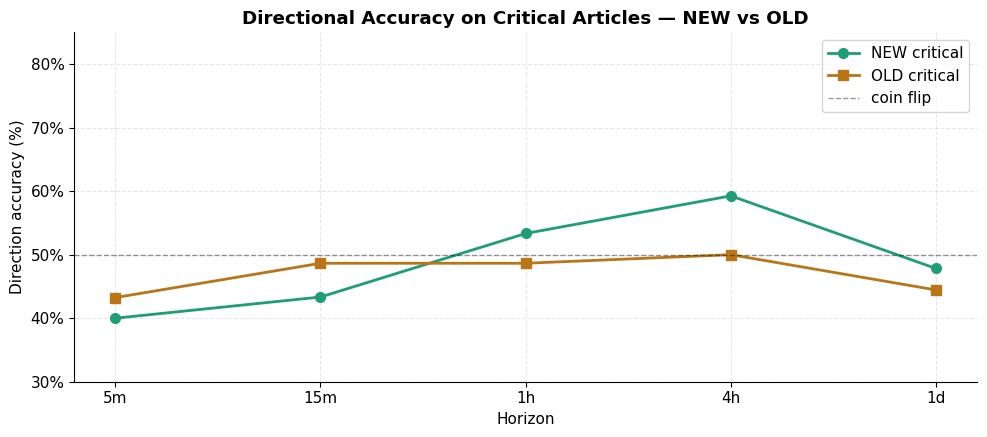

In [20]:
fig, ax = plt.subplots(figsize=(10, 4.5))

for label, crit_col, dir_col, color, style in [
    ('NEW critical', 'is_critical_new', 'direction_new', TEAL,  '-o'),
    ('OLD critical', 'is_critical_old', 'direction_old', AMBER, '-s'),
]:
    grp = joined[joined[crit_col] == True]
    accs = []
    for h in HORIZONS:
        acc, _ = dir_accuracy(grp, h, dir_col=dir_col)
        accs.append(acc*100 if not np.isnan(acc) else np.nan)
    ax.plot(H_LABELS, accs, style, label=label, color=color, linewidth=2, markersize=7)

ax.axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.4, label='coin flip')
ax.set_ylabel('Direction accuracy (%)'); ax.set_xlabel('Horizon')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(30, 85)
ax.set_title('Directional Accuracy on Critical Articles — NEW vs OLD', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 9 — Headline Numbers

In [21]:
new_rel  = joined['is_relevant_new'].sum()
old_rel  = joined['is_relevant_old'].sum()
new_crit = joined['is_critical_new'].sum()
old_crit = joined['is_critical_old'].sum()

new_lift_15m = joined.loc[joined['is_critical_new']==True, 'pct_15m'].abs().mean() / joined.loc[joined['is_critical_new']==False, 'pct_15m'].abs().mean()
old_lift_15m = joined.loc[joined['is_critical_old']==True, 'pct_15m'].abs().mean() / joined.loc[joined['is_critical_old']==False, 'pct_15m'].abs().mean()
_, p_new = mannwhitneyu(joined.loc[joined['is_critical_new']==True,  'pct_15m'].abs().dropna(),
                         joined.loc[joined['is_critical_new']==False, 'pct_15m'].abs().dropna(),
                         alternative='greater')
_, p_old = mannwhitneyu(joined.loc[joined['is_critical_old']==True,  'pct_15m'].abs().dropna(),
                         joined.loc[joined['is_critical_old']==False, 'pct_15m'].abs().dropna(),
                         alternative='greater')

new_acc, new_n = dir_accuracy(joined[joined['is_critical_new']==True], 'pct_15m', 'direction_new')
old_acc, old_n = dir_accuracy(joined[joined['is_critical_old']==True], 'pct_15m', 'direction_old')

prf_new = prf(joined, 'criticality_level_new')
prf_old = prf(joined, 'criticality_level_old')

print('=' * 72)
print('  HEADLINE NUMBERS — NEW vs OLD on the same 187 articles')
print('=' * 72)
print(f'  Articles compared            : {len(joined)}')
print()
print(f'  Relevant          NEW / OLD  : {new_rel:3d} / {old_rel:3d}')
print(f'  Critical (flag)   NEW / OLD  : {new_crit:3d} / {old_crit:3d}')
print(f'  Both agree critical          : {int(((joined["is_critical_new"]) & (joined["is_critical_old"])).sum())}')
print(f'  Only NEW critical            : {int(((joined["is_critical_new"]) & (~joined["is_critical_old"])).sum())}')
print(f'  Only OLD critical            : {int(((~joined["is_critical_new"]) & (joined["is_critical_old"])).sum())}')
print()
print('  VOLATILITY SIGNAL @ 15m')
print(f'  NEW lift (crit / not)        : {new_lift_15m:.2f}x   MW p = {p_new:.4f}')
print(f'  OLD lift (crit / not)        : {old_lift_15m:.2f}x   MW p = {p_old:.4f}')
print()
print('  DIRECTIONAL ACCURACY @ 15m (critical subset)')
print(f'  NEW                          : {new_acc*100:.1f}%  (n={new_n})')
print(f'  OLD                          : {old_acc*100:.1f}%  (n={old_n})')
print()
print('  PRECISION vs ROLLING-SD TRUTH')
print(f'  NEW  precision/recall/F1     : {prf_new["precision"]:>6} / {prf_new["recall"]:>6} / {prf_new["F1"]:>5}')
print(f'  OLD  precision/recall/F1     : {prf_old["precision"]:>6} / {prf_old["recall"]:>6} / {prf_old["F1"]:>5}')
print('=' * 72)

  HEADLINE NUMBERS — NEW vs OLD on the same 187 articles
  Articles compared            : 187

  Relevant          NEW / OLD  : 176 / 187
  Critical (flag)   NEW / OLD  :  31 /  39
  Both agree critical          : 23
  Only NEW critical            : 8
  Only OLD critical            : 16

  VOLATILITY SIGNAL @ 15m
  NEW lift (crit / not)        : 1.95x   MW p = 0.0161
  OLD lift (crit / not)        : 2.31x   MW p = 0.0020

  DIRECTIONAL ACCURACY @ 15m (critical subset)
  NEW                          : 43.3%  (n=30)
  OLD                          : 48.6%  (n=37)

  PRECISION vs ROLLING-SD TRUTH
  NEW  precision/recall/F1     :  56.7% /  25.8% / 0.354
  OLD  precision/recall/F1     :  56.8% /  29.6% / 0.389
